# RevPAR Optimization Demo

This notebook demonstrates the components and the solution of the Linear Programming (LP) model for hotel revenue optimization (RevPAR).

## Optimization Components:
1. **Price Grid ($p_k$):** The discrete set of prices we can choose from.
2. **Demand Matrix ($D_{d,k}$):** Predicted demand for each day $d$ and price $p_k$. 
3. **Revenue Matrix ($R_{d,k}$):** Potential revenue ($p_k \cdot D_{d,k}$).
4. **Capacity ($C$):** The hotel's total inventory constraint.


$$
\begin{align*}
\lambda_{d,k} &\ge 0 \\
price_d &\ge 0 \\
quantity_d &\ge 0 \\
revenue_d &\ge 0
\end{align*}
$$

**Objective**

$$
\max \sum_{d \in D} revenue_d
$$

**Constraints**

$$
\sum_{k \in K} \lambda_{d,k} = 1
\quad \forall d
$$


The final, blended dollar amount charged on day $d$.
$$
price_d = \sum_{k \in K} \lambda_{d,k} p_k
$$
The final, blended number of rooms expected to sell.
$$
quantity_d = \sum_{k \in K} \lambda_{d,k} D_{d,p_k}
$$
The final, blended money made.
$$
revenue_d = \sum_{k \in K} \lambda_{d,k} R_{d,p_k}
$$

Capacity:
$$
\sum_{d \in D} quantity_d \le C
$$

In [14]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path to allow imports
sys.path.append(os.path.abspath('..'))

from Optimization.models.lp_model import LPOptimizationModel
from Optimization.utils.data_utils import generate_sample_demand

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Configuration & Price Grid

First, we define the optimization horizon (days), the capacity, and the price range.

Price Grid: [100. 150. 200. 250. 300. 350. 400. 450. 500. 550. 600.]


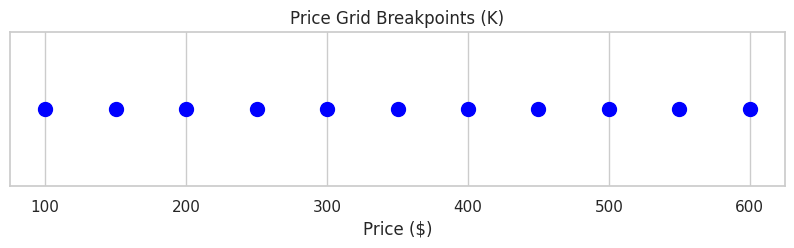

In [15]:
config = {
    "capacity": 50,
    "horizon": 14,      # 2 weeks
    "min_price": 100.0,
    "max_price": 600.0,
    "num_breakpoints": 11,
    "use_soft_capacity": False
}

model = LPOptimizationModel(config)
print(f"Price Grid: {model.price_grid}")

plt.figure(figsize=(10, 2))
plt.scatter(model.price_grid, np.zeros_like(model.price_grid), color='blue', s=100)
plt.title("Price Grid Breakpoints (K)")
plt.xlabel("Price ($)")
plt.yticks([])
plt.show()

## 2. Demand Prediction Matrix ($D_{d,k}$)

We generate a demand matrix where each entry represents the expected number of rooms sold for a given day at a specific price.

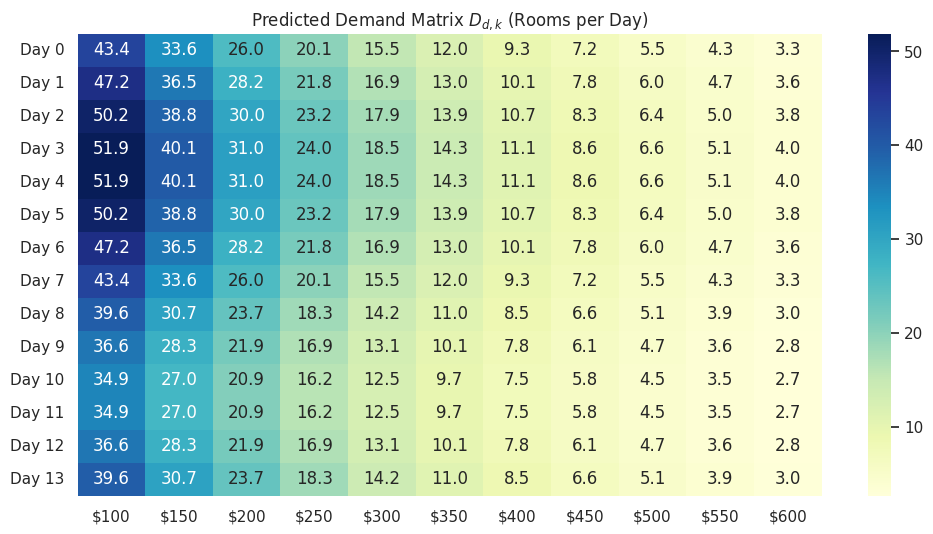

In [16]:
demand_matrix = generate_sample_demand(
    horizon=config['horizon'],
    price_grid=model.price_grid,
    base_demand=12.0,
    elasticity=1.8
)
model.set_demand_data(demand_matrix)

df_demand = pd.DataFrame(
    demand_matrix, 
    columns=[f"${p:.0f}" for p in model.price_grid],
    index=[f"Day {d}" for d in range(config['horizon'])]
)

plt.figure(figsize=(12, 6))
sns.heatmap(df_demand, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Predicted Demand Matrix $D_{d,k}$ (Rooms per Day)")
plt.show()

## 3. Potential Revenue Matrix ($R_{d,k}$)

The revenue matrix is simply $p_k \cdot D_{d,k}$. This shows which price point is locally optimal for each day without considering capacity.

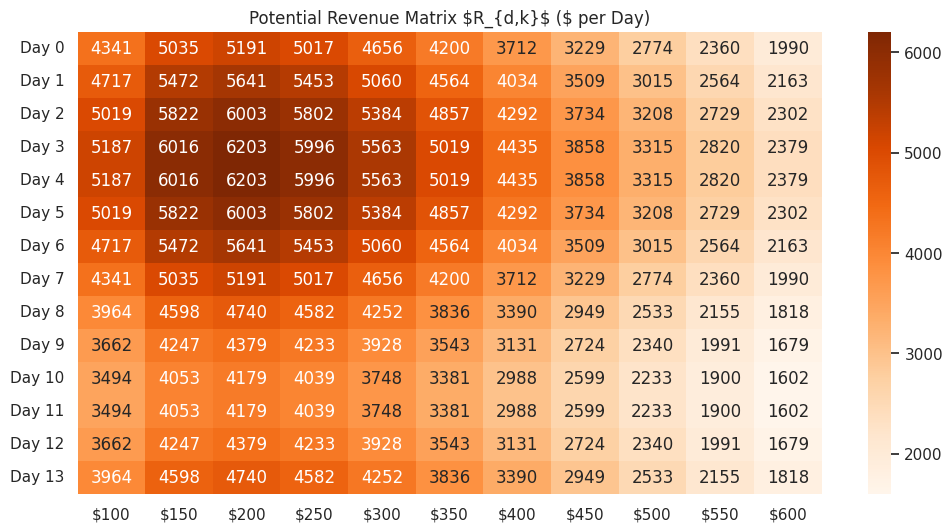

In [17]:
df_revenue = pd.DataFrame(
    model.revenue_matrix, 
    columns=[f"${p:.0f}" for p in model.price_grid],
    index=[f"Day {d}" for d in range(config['horizon'])]
)

plt.figure(figsize=(12, 6))
sns.heatmap(df_revenue, annot=True, fmt=".0f", cmap="Oranges")
plt.title("Potential Revenue Matrix $R_{d,k}$ ($ per Day)")
plt.show()

## 4. Run Optimization

Now we solve the LP model to find the best mix of prices over the 14-day horizon that stays within the 100-room capacity.

In [18]:
results = model.solve()

if results["status"] == "OPTIMAL":
    print(f"Optimization Successful!")
    print(f"Total Revenue: ${results['objective']:.2f}")
    print(f"Total Rooms Sold: {results['total_demand']:.1f} / {config['capacity']}")
else:
    print("Optimization failed.")

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: AMD Ryzen 9 9950X3D 16-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 16 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 57 rows, 196 columns and 672 nonzeros (Max)
Model fingerprint: 0xf4757ab4
Model has 14 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 6e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 6e+02]
  RHS range        [1e+00, 5e+01]

Presolve removed 28 rows and 28 columns
Presolve time: 0.00s
Presolved: 29 rows, 168 columns, 476 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    7.2671889e+04   1.220899e+02   0.000000e+00      0s
      84    2.9215874e+04   0.000000e+00   0.000000e+00      0s

Solved in 84 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.921587441e+04
Optimization Successful!
Total Revenue: $29215.87
Tot

## 5. Result Analysis

Let's look at the optimal price and demand for each day.

/tmp/ipykernel_73952/1408505264.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right')


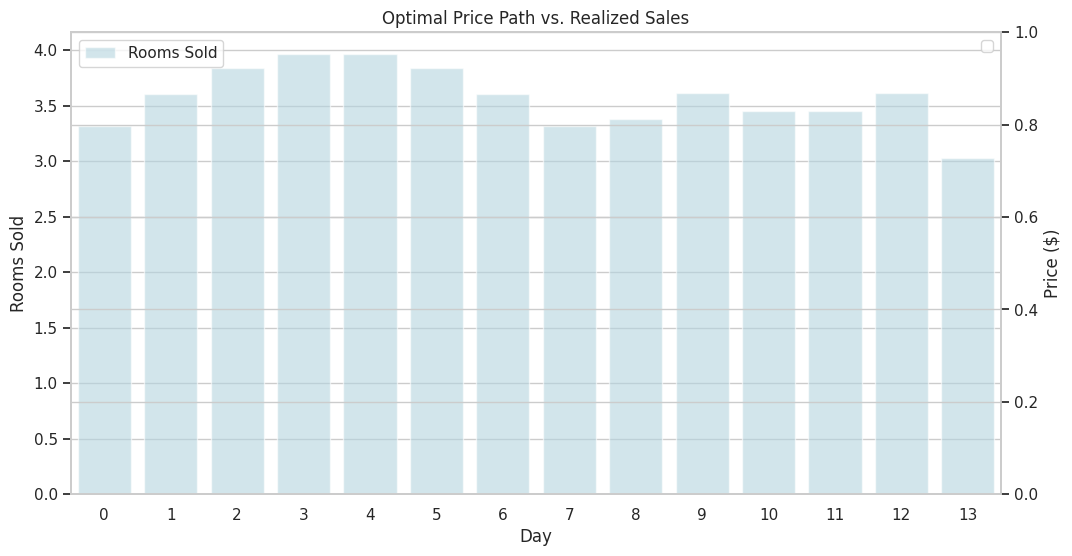

,Day,Price,Demand,Revenue
0,0,600.000000,3.317437,1990.461936
1,1,600.000000,3.605313,2163.187749
2,2,600.000000,3.836172,2301.703097
3,3,600.000000,3.964289,2378.573316
4,4,600.000000,3.964289,2378.573316
5,5,600.000000,3.836172,2301.703097
6,6,600.000000,3.605313,2163.187749
7,7,600.000000,3.317437,1990.461936
8,8,580.392326,3.377933,1949.938362
9,9,550.000000,3.619364,1990.650244


In [19]:
res_df = pd.DataFrame({
    "Day": range(config['horizon']),
    "Price": results["prices"],
    "Demand": results["quantities"],
    "Revenue": results["revenues"]
})

fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
sns.barplot(x="Day", y="Demand", data=res_df, ax=ax1, color='lightblue', alpha=0.6, label="Rooms Sold")
# sns.lineplot(x="Day", y="Price", data=res_df, ax=ax2, color='red', marker='o', label="Optimal Price")

ax1.set_ylabel("Rooms Sold")
ax2.set_ylabel("Price ($)")
plt.title("Optimal Price Path vs. Realized Sales")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

display(res_df)